# Continuous-time linear demo


In [1]:
import jax
from jax import config


config.update("jax_enable_x64", True)

from cmap.clqt_jax import CLQT
from cmap.Linear_model_jax import getCLQT 
import matplotlib.pyplot as plt
import jax.numpy as jnp
from cmap.Linear_model_data import make_cv_data
from cmap.con_to_dis import y
# config.update("jax_platform_name", "cuda")


In [2]:
from cmap.kalman_bucy import kalman_bucy_filter
from cmap.kalman_bucy import continuous_rts_smoother


In [3]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass


In [4]:
steps_all=50000

In [5]:
clqt, x0,P0,q,v = getCLQT(steps_all)

ERROR:2025-10-29 14:01:46,505:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN


In [6]:
t0=0.0
dt=clqt.T/steps_all

q=q
r=v
X,y_discrete,y_discrete_rev=make_cv_data( x0, P0(0),steps_all, dt, q, r, seed=123)

In [7]:
y_meas=lambda t: y(t,dt,steps_all,y_discrete)

In [8]:
t_grid = jnp.arange(steps_all) * dt
s=jnp.stack([y_meas(t) for t in t_grid], axis=0)
DY_dt_recovered = jnp.stack([y_meas(t) for t in t_grid], axis=0)
jnp.shape(DY_dt_recovered)
# np.savetxt('con-meas.txt',dotz)

(50000, 2)

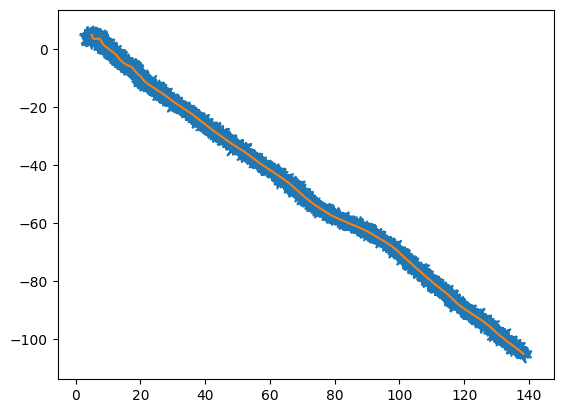

In [9]:
plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
plt.plot(X[:,0], X[:,1], label='True velocity x')


In [10]:
T=clqt.T
F=lambda t: -clqt.F(T-t)
L=lambda t: -clqt.L(T-t)
H=lambda t: clqt.H(T-t)
W=lambda t: clqt.W(T-t)
R=lambda t: clqt.R(T-t)



step_seq=steps_all
print(step_seq)

dt=clqt.T/step_seq

t_eval = t0 + dt * jnp.arange(step_seq)

Ps,ms = kalman_bucy_filter(F, L, W, H, R, y_meas, step_seq, dt,t0, P0(0), x0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, W, t_eval, dt)


50000


In [11]:

blocks = 500
steps = 100
T=clqt.T
dt = clqt.T / steps / blocks
sigma=clqt.Sigma(0)
mu=clqt.mu

S_seq, v_seq,Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,sigma,mu)
phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
x_seq,u_seq =seqForwardPass(clqt, dt, T, phi0, Kx_seq, d_seq,u_zoh=False)


In [12]:
phis = jnp.linalg.solve(S_seq, v_seq[..., None]).squeeze(-1)


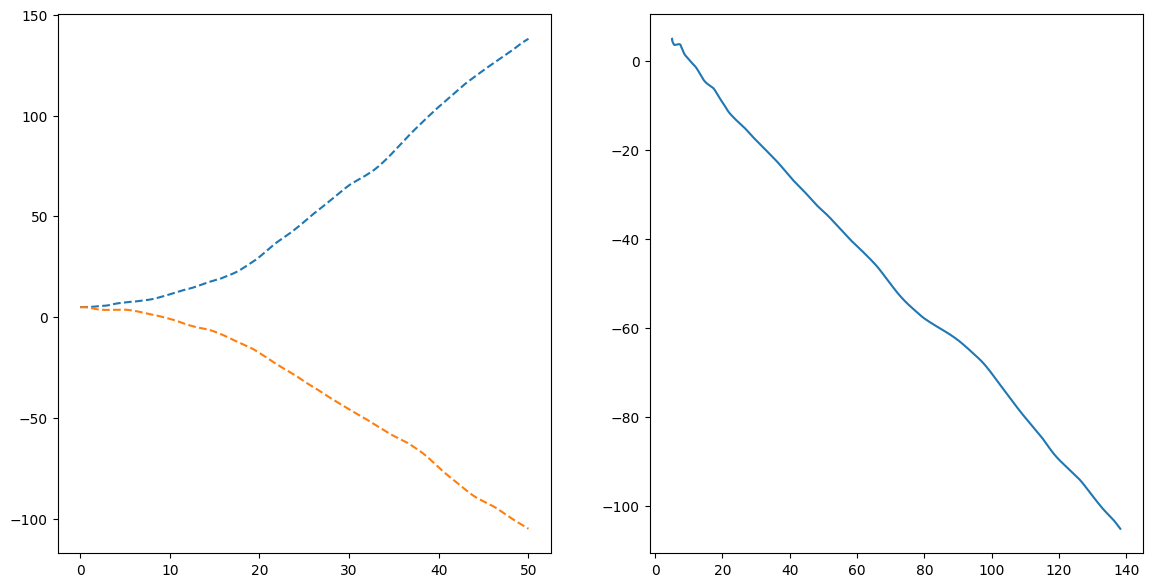

In [13]:
xs3 = jnp.array(x_seq)[::-1]
us3 = jnp.array(u_seq)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])


In [14]:
dt = clqt.T / steps / blocks

Kx_par, d_par, S_par, v_par = parBackwardPass(clqt,blocks,steps,t0,dt)
phi0= jnp.linalg.solve(S_par[0] ,v_par[0])

u_par,x_par = parForwardPass(clqt, phi0, Kx_par, d_par, blocks, steps,dt,t0,u_zoh=False)



In [15]:
phis1 = jnp.linalg.solve(S_par, v_par[..., None]).squeeze(-1)


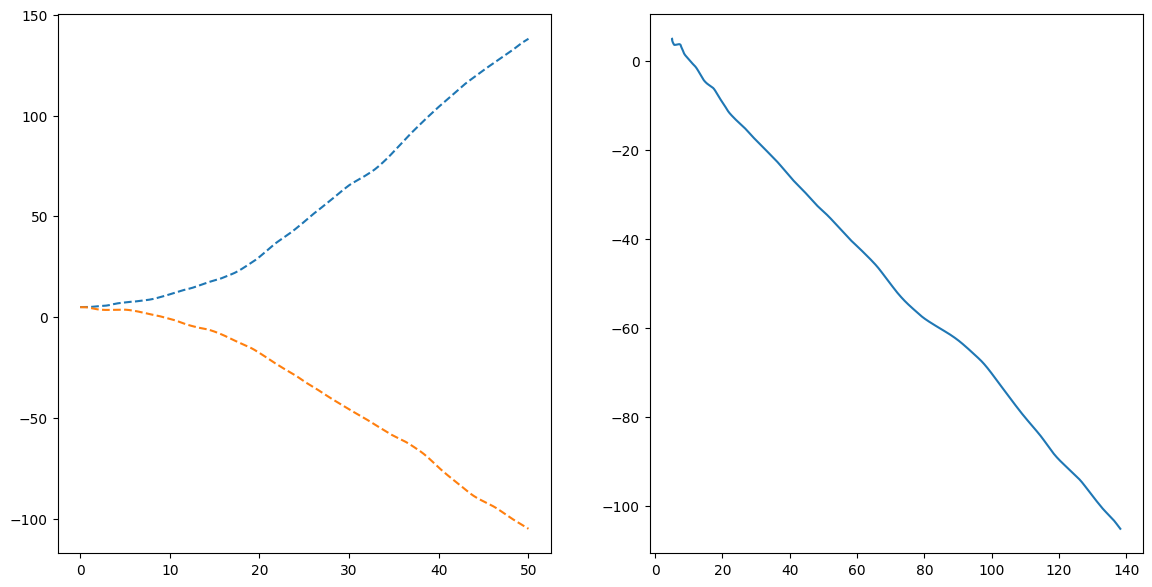

In [16]:
xs4 = jnp.array(x_par)[::-1]

us4 = jnp.array(u_par)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


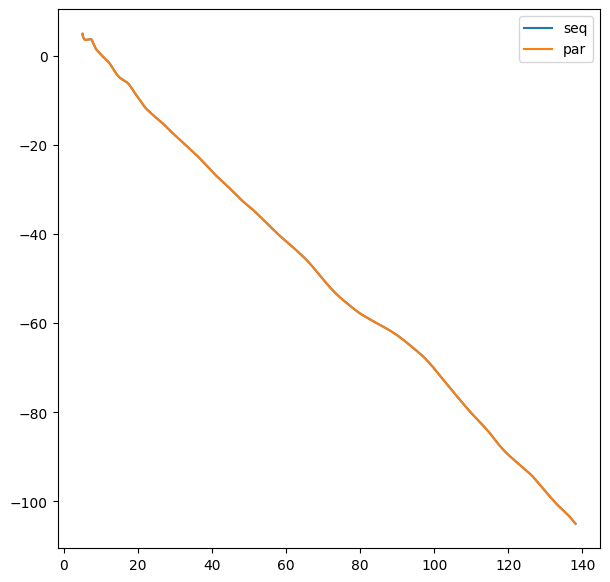

In [17]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1])
ax1.legend( ['seq', 'par'])


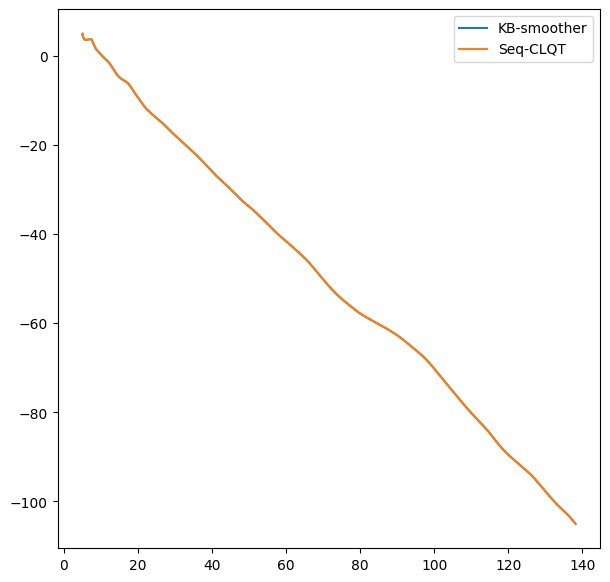

In [18]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms_s[:,0], ms_s[:,1])
ax1.plot(xs3[:,0], xs3[:,1])
ax1.legend( ['KB-smoother', 'Seq-CLQT'])


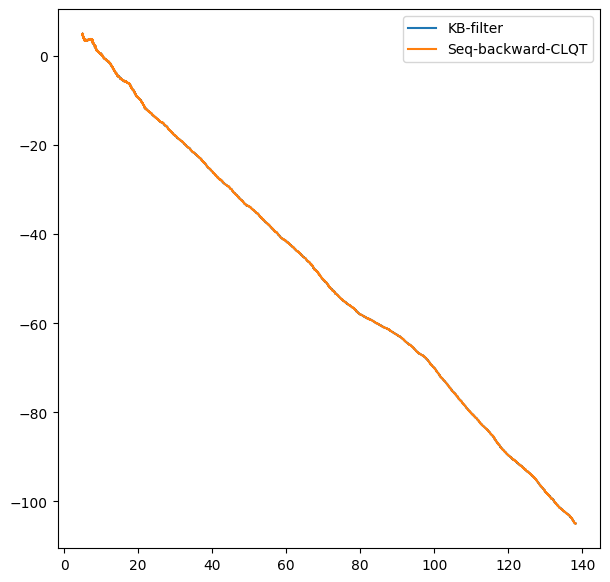

In [19]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms[:,0], ms[:,1])
ax1.plot(phis[:,0], phis[:,1])
ax1.legend( ['KB-filter', 'Seq-backward-CLQT'])


In [20]:
err = jnp.max(jnp.abs(xs4- xs3))
print(err)

0.004560356709276903


In [21]:
print(jnp.max(jnp.abs(xs3-ms_s)))

0.004861730663932917


In [22]:
print(jnp.max(jnp.abs(phis[::-1]-ms)))

0.000817330379943873
